# ARIMA Forecasting Initial Exploration
### Aim
I want to use the FTSE 100 and FTSE 250 stock price data to try an ARIMA model following the datacamp tutorial [here](https://www.datacamp.com/tutorial/arima).
The decision tree model I tried in the initial data exploration notebook performed poorly. I want to try ARIMA here to see if it performs better.

In [1]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA 
from sklearn.metrics import mean_squared_error

In [2]:
ftse100_path = '../data/raw//ftse_100_historic_prices.csv'
ftse250_path = '../data/raw/ftse_250_historic_prices.csv'
ftse100 = pd.read_csv(ftse100_path)
ftse250 = pd.read_csv(ftse250_path)

ftse100['Date'] = pd.to_datetime(ftse100['Date'])
ftse250['Date'] = pd.to_datetime(ftse250['Date'])
for data in [ftse100, ftse250]:
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month
    data["DOM"] = data["Date"].dt.day
    data["Day"] = data["Date"].dt.dayofweek
    data["Week"] = data["Date"].dt.isocalendar().week
    data['DOY'] = data['Date'].dt.dayofyear

In [3]:
ftse100Cons = ftse100['Company'].unique()
ftse250Cons = ftse250['Company'].unique()

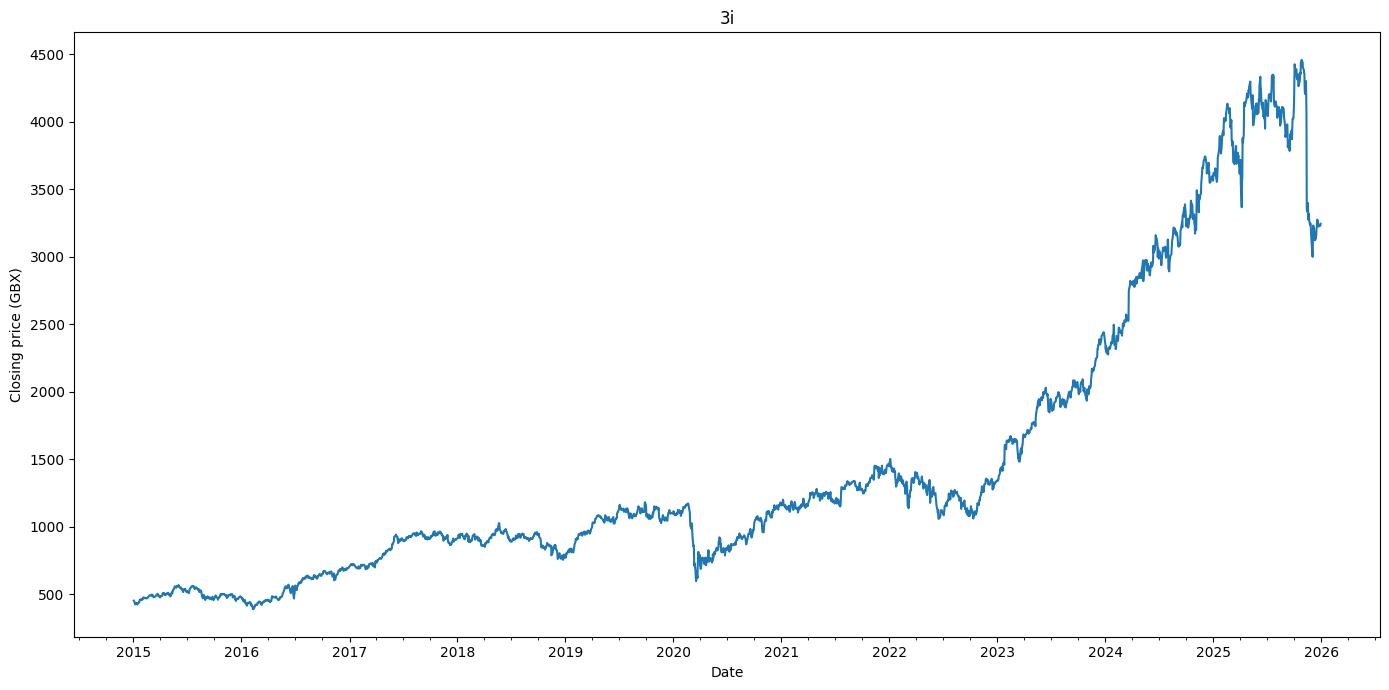

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))

subset = ftse100.loc[ftse100['Company'] == "3i"]
ax.plot(subset['Date'], subset['Close'], label="3i")
ax.set_xlabel("Date")
ax.set_ylabel("Closing price (GBX)")
ax.set_title("3i")
ax.xaxis.set_major_locator(matplotlib.dates.YearLocator())
ax.xaxis.set_minor_locator(matplotlib.dates.MonthLocator((1,4,7,10)))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))


plt.tight_layout()
plt.show()

According to the tutorial, ARIMA requires data to generally be non-stationary and they cannot deal with time-varying variance. As with all stocks, there is a high degree of time based variability. Will use the tutorials recommended Augmented Dickey-Fuller test to check whether the time series is stationary or not (strongly suspect not).

In [5]:
# Perform the Augmented Dickey-Fuller test on the original series
result_original = adfuller(subset["Close"])
print(f"ADF Statistic (Original): {result_original[0]:.4f}")
print(f"p-value (Original): {result_original[1]:.4f}")
if result_original[1] < 0.05:
    print("Interpretation: The original series is Stationary.\n")
else:
    print("Interpretation: The original series is Non-Stationary.\n")
# Apply first-order differencing
subset['Close_Diff'] = subset['Close'].diff()
# Perform the Augmented Dickey-Fuller test on the differenced series
result_diff = adfuller(subset["Close_Diff"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")
if result_diff[1] < 0.05:    
    print("Interpretation: The differenced series is Stationary.")
else:    
    print("Interpretation: The differenced series is Non-Stationary.")

ADF Statistic (Original): -0.2603
p-value (Original): 0.9309
Interpretation: The original series is Non-Stationary.

ADF Statistic (Differenced): -13.7891
p-value (Differenced): 0.0000
Interpretation: The differenced series is Stationary.


Side note, I want to find some way of doing a long-term identification of differences not just day to day, but look more widely across the time series data to find th e largest relative change in stock price and see if that is a change that can be explained by seasonal variation. The aim of this is to find a regular increase in stock price that can be capitalised on to get a low effort decent return.

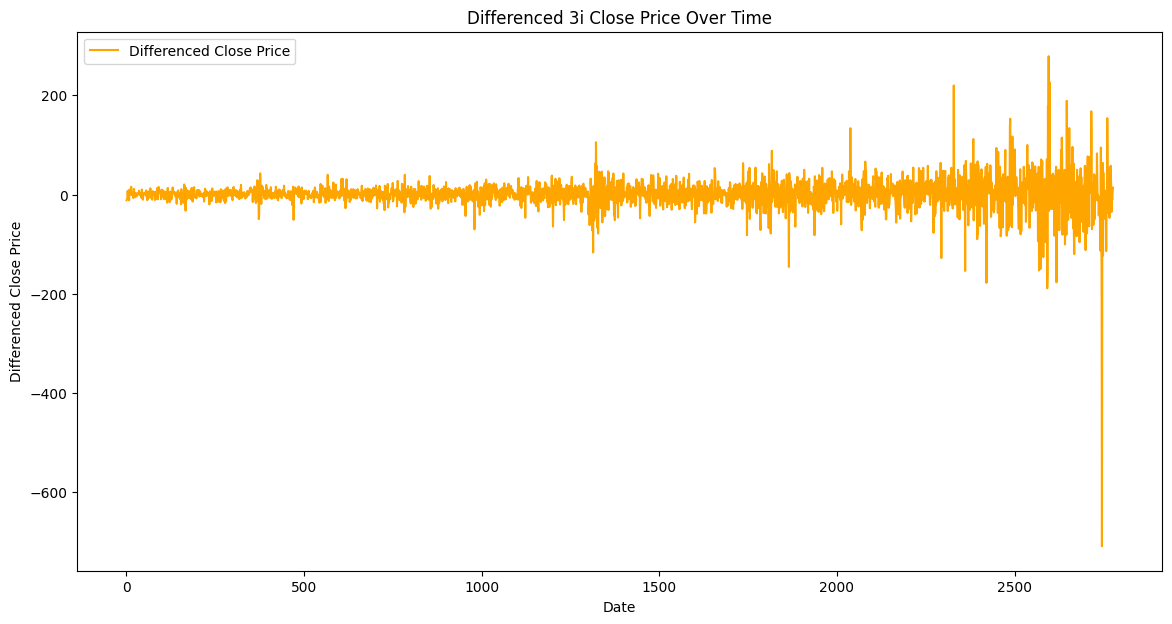

In [6]:
# Plotting the differenced Close price
plt.figure(figsize=(14, 7))
plt.plot(subset.index, subset['Close_Diff'], label='Differenced Close Price', color='orange')
plt.title('Differenced 3i Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Differenced Close Price')
plt.legend()
plt.show()

Will keep exploring with the 3i price to start with, but will script this to try and automatically get the *p*, *d*, and *q* parameters of the ARIMA model.

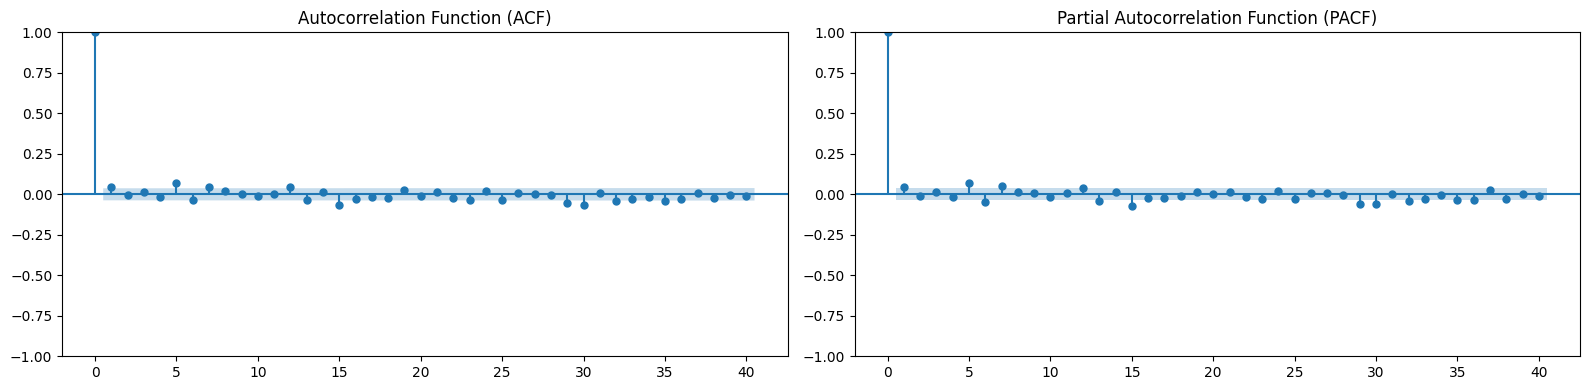

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt # Plot ACF and PACF for the differenced series

fig, axes = plt.subplots(1, 2, figsize=(16, 4))# ACF plot
plot_acf(subset['Close_Diff'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')# PACF plot
plot_pacf(subset['Close_Diff'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

In [8]:
subset

,Date,Close,Open,High,Low,Volume,Company,Ticker,Sector,Year,Month,DOM,Day,Week,DOY,Close_Diff
0,2015-01-02,452.359253,453.156350,453.156350,446.580226,1301344,3i,III,Financial services,2015,1,2,4,1,2,NaN
1,2015-01-05,440.801086,450.266752,456.544001,440.801086,2283053,3i,III,Financial services,2015,1,5,0,2,5,-11.558167
2,2015-01-06,431.634369,439.804715,441.767596,431.435080,2017730,3i,III,Financial services,2015,1,6,1,2,6,-9.166718
3,2015-01-07,424.161530,432.531166,434.723197,423.962240,3278264,3i,III,Financial services,2015,1,7,2,2,7,-7.472839
4,2015-01-08,431.435120,428.944155,432.603884,425.456804,2749614,3i,III,Financial services,2015,1,8,3,2,8,7.273590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2773,2025-12-22,3240.000000,3249.000000,3289.000000,3194.000000,1190599,3i,III,Financial services,2025,12,22,0,52,356,-35.000000
2774,2025-12-23,3235.000000,3250.000000,3287.000000,3224.000000,989307,3i,III,Financial services,2025,12,23,1,52,357,-5.000000
2775,2025-12-24,3224.000000,3206.000000,3250.000000,3206.000000,298101,3i,III,Financial services,2025,12,24,2,52,358,-11.000000
2776,2025-12-29,3230.000000,3226.000000,3277.000000,3217.000000,775548,3i,III,Financial services,2025,12,29,0,1,363,6.000000


Looks like we want to use a value of 1 for both *p* and *d* parameters given the value observed of 1 and the fall off after that.

In [9]:
# Set the index as the date column otherwise ARIMA won't work
subset.set_index("Date", inplace=True)

In [14]:
subset.head()

,Close,Open,High,Low,Volume,Company,Ticker,Sector,Year,Month,DOM,Day,Week,DOY,Close_Diff
Date,,,,,,,,,,,,,,,
2015-01-02,452.359253,453.156350,453.156350,446.580226,1301344,3i,III,Financial services,2015,1,2,4,1,2,NaN
2015-01-05,440.801086,450.266752,456.544001,440.801086,2283053,3i,III,Financial services,2015,1,5,0,2,5,-11.558167
2015-01-06,431.634369,439.804715,441.767596,431.435080,2017730,3i,III,Financial services,2015,1,6,1,2,6,-9.166718
2015-01-07,424.161530,432.531166,434.723197,423.962240,3278264,3i,III,Financial services,2015,1,7,2,2,7,-7.472839
2015-01-08,431.435120,428.944155,432.603884,425.456804,2749614,3i,III,Financial services,2015,1,8,3,2,8,7.273590


In [20]:
train.head()

,Close,Open,High,Low,Volume,Company,Ticker,Sector,Year,Month,DOM,Day,Week,DOY,Close_Diff
Date,,,,,,,,,,,,,,,
2015-01-02,452.359253,453.156350,453.156350,446.580226,1301344,3i,III,Financial services,2015,1,2,4,1,2,NaN
2015-01-05,440.801086,450.266752,456.544001,440.801086,2283053,3i,III,Financial services,2015,1,5,0,2,5,-11.558167
2015-01-06,431.634369,439.804715,441.767596,431.435080,2017730,3i,III,Financial services,2015,1,6,1,2,6,-9.166718
2015-01-07,424.161530,432.531166,434.723197,423.962240,3278264,3i,III,Financial services,2015,1,7,2,2,7,-7.472839
2015-01-08,431.435120,428.944155,432.603884,425.456804,2749614,3i,III,Financial services,2015,1,8,3,2,8,7.273590


In [21]:
# Split data into train and test
train_size = int(0.8 * len(subset))
train, test = subset.iloc[:train_size], subset.iloc[train_size:]
# Fit ARIMA model
model = ARIMA(train["Close"], order=(1,1,1))
model_fit = model.fit()

/home/alexb/Documents/personal_projects/stock_price_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/alexb/Documents/personal_projects/stock_price_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/alexb/Documents/personal_projects/stock_price_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/alexb/Documents/personal_projects/stock_price_analysis/.venv/lib/python3.11/

/home/alexb/Documents/personal_projects/stock_price_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/alexb/Documents/personal_projects/stock_price_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


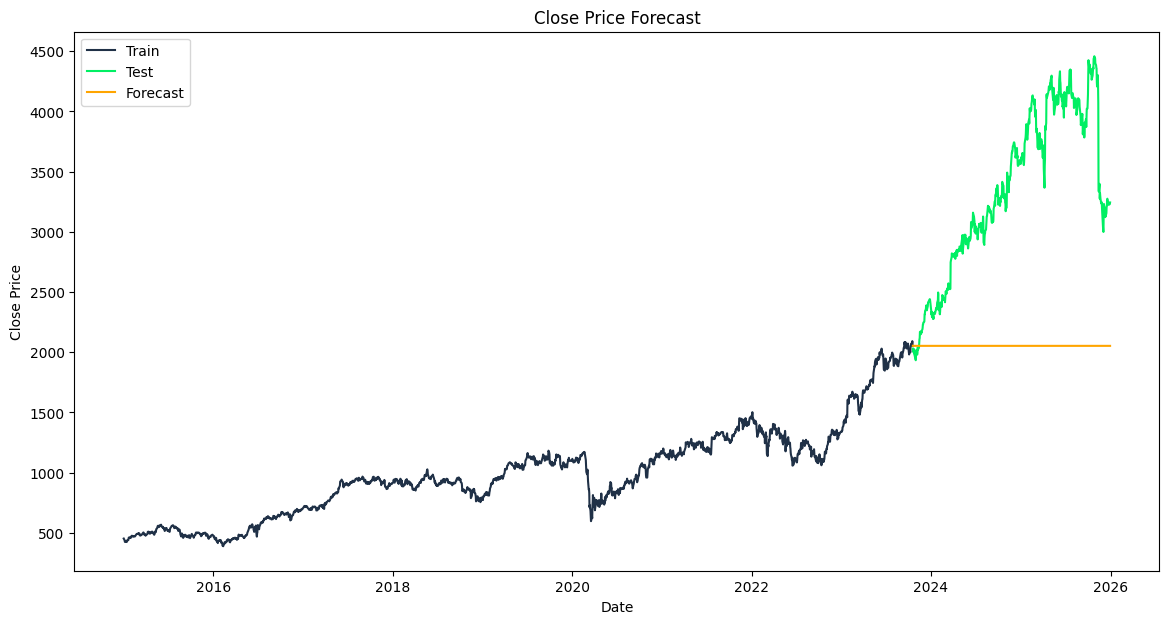

In [22]:
# Forecast
forecast = model_fit.forecast(steps=len(y_test))
# Plot the results with specified colors
plt.figure(figsize=(14,7))
plt.plot(train.index, train["Close"], label='Train', color='#203147')
plt.plot(test.index, test["Close"], label='Test', color='#01ef63')
plt.plot(test.index, forecast, label='Forecast', color='orange')
plt.title('Close Price Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

Not exactly informative. I'll try adding additional parameters to the model to see if that improves the predictions, or at the very least, give some predicted values that actually change.

In [23]:
print(f"AIC: {model_fit.aic}")
print(f"BIC: {model_fit.bic}")

AIC: 19121.527074141337
BIC: 19138.64421261302


In [24]:
forecast = forecast[:len(test)]
test_close = test["Close"][:len(forecast)]# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test_close, forecast))
print(f"RMSE: {rmse:.4f}")

RMSE: 1456.7141


Just checking various metrics and this model is, as we can see in the plot, not good at picking up the patterns. This is the end of what the tutorial so I'll have to do my own reading to see what to do next (shocker).